In [2]:
import keras
import tensorflow as tf
from IPython.display import Image
import matplotlib.pyplot as plt
from keras import layers
from keras import ops


In [3]:
print(tf.reduce_sum(tf.random.normal([1000, 1000])))

tf.Tensor(-1078.8488, shape=(), dtype=float32)


In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=(96, 96),   # downscaling
    color_mode="grayscale",
    batch_size=32
)

Found 2128 files belonging to 3 classes.


In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=(96, 96),   # downscaling
    color_mode="grayscale",
    batch_size=32
)


Found 766 files belonging to 3 classes.


1


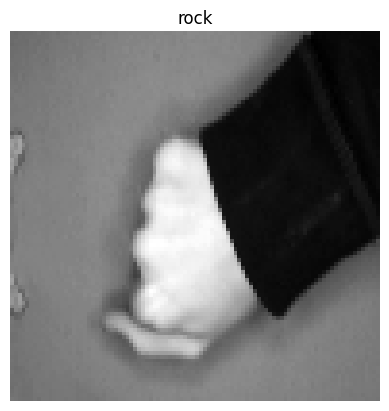

In [6]:

class_names = train_dataset.class_names

for images, labels in train_dataset.take(1):

    image = images[0].numpy()
    label = labels[0].numpy()
    
    print(label)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [7]:
model = keras.Sequential(
    [
   layers.Conv2D(24, (3, 3), activation="relu", input_shape=(96, 96, 1)),
   layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3,activation='softmax')

    ]
)

c:\Users\loren\anaconda3\envs\MLstat\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 53016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,393,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393,523 (12.95 MB)

 Trainable params: 3,393,523 (12.95 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(train_dataset, validation_data=validation_dataset, epochs=10)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3967 - loss: 130.6119 - val_accuracy: 0.2076 - val_loss: 5.1520
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8121 - loss: 1.9093 - val_accuracy: 0.9817 - val_loss: 0.1499
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9384 - loss: 0.3168 - val_accuracy: 0.9830 - val_loss: 0.1038
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9318 - loss: 0.3247 - val_accuracy: 0.9674 - val_loss: 0.1467
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9889 - loss: 0.0405 - val_accuracy: 0.9491 - val_loss: 0.2225
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9233 - loss: 0.5168 - val_accuracy: 0.9909 - val_loss: 0.0927
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9789 - loss: 0.0623 - val_accuracy: 0.9778 - val_loss: 0.1311
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9537 - loss: 0.2416 - val_accuracy: 0.9883 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted label: rock
Actual label: rock


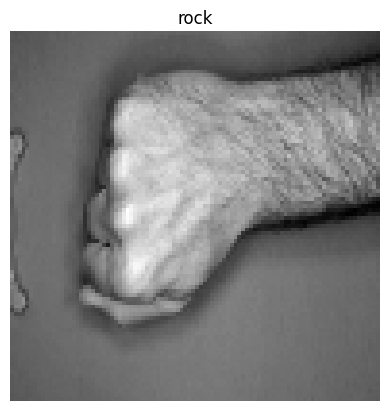

In [14]:
for images, labels in validation_dataset.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()